## Explore Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [5]:
df_net = pd.read_csv('../data/raw/netflix_movies.csv')
df_net.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [6]:
df_net.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df_net.shape

(8807, 12)

In [8]:
df_net.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df_net.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,15-Aug,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,3207,1793,362,4


### Handling Missing Values

In [10]:
df_net.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
df_net.duplicated().sum()

np.int64(0)

In [12]:
df_net['director'].value_counts()

director
Rajiv Chilaka                     19
Raúl Campos, Jan Suter            18
Marcus Raboy                      16
Suhas Kadav                       16
Jay Karas                         14
                                  ..
Raymie Muzquiz, Stu Livingston     1
Joe Menendez                       1
Eric Bross                         1
Will Eisenberg                     1
Mozez Singh                        1
Name: count, Length: 4528, dtype: int64

In [13]:
df_net['director'] = df_net['director'].fillna('Not Available')

In [14]:
df_net.dropna(inplace=True)

In [15]:
df_net.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [16]:
print(df_net.shape)
df_net.columns

(7290, 12)


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [17]:
# Saving the cleaned dataframe to a new CSV file

df_net.to_csv('../data/processed/netflix_movies_cleaned.csv', index=False)

### Feature Engineering

Conversion of duration column dtype to date_time dtype and spliting it to year, month, day columns

In [18]:
df_net['date'] = pd.to_datetime(df_net['date_added'].str.strip(), errors='coerce')

df_net['day'] = df_net['date'].dt.day.astype('Int64')
df_net['month'] = df_net['date'].dt.month.astype('Int64')
df_net['year'] = df_net['date'].dt.year.astype('Int64')

df_net.drop(['date_added', 'date'], axis=1, inplace=True)

In [19]:
df_net.sample(3)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year
3280,s3281,Movie,The Garden of Words,Makoto Shinkai,"Miyu Irino, Kana Hanazawa, Fumi Hirano, Takesh...",Japan,2013,TV-14,46 min,"Anime Features, International Movies, Romantic...",When a lonely teenager skips his morning class...,15,11,2019
3218,s3219,Movie,Holiday Rush,Leslie Small,"Romany Malco, Sonequa Martin-Green, Darlene Lo...",United States,2019,TV-PG,94 min,"Children & Family Movies, Dramas",A widowed radio DJ and his four spoiled kids n...,28,11,2019
7751,s7752,Movie,Platoon,Oliver Stone,"Tom Berenger, Willem Dafoe, Charlie Sheen, For...","United States, United Kingdom",1986,R,120 min,"Action & Adventure, Classic Movies, Dramas",A soldier grows disillusioned as he's caught b...,1,11,2020


In [20]:
df_net[df_net.isna().any(axis=1)]

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year


## EDA

### 1. Univariate Analysis

#### 1. Which type of content is more prevalent on platforms: Movies & TV Shows ?

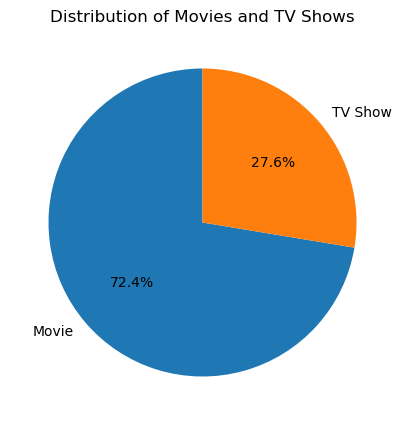

type
Movie      5277
TV Show    2013
Name: count, dtype: int64

In [21]:
plt.figure(figsize=(5,5))
type_counts = df_net['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct= '%.1f%%', startangle=90)
plt.title('Distribution of Movies and TV Shows')
plt.show()

type_counts

#### 2. Top 10 directors by number of titles ?

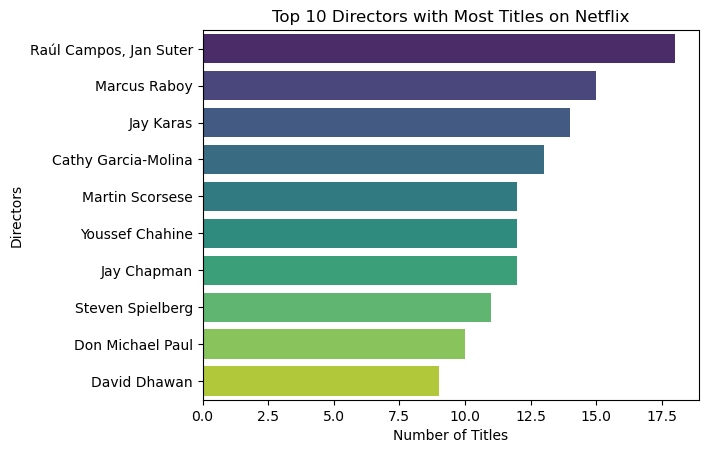

director
Raúl Campos, Jan Suter    18
Marcus Raboy              15
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Don Michael Paul          10
David Dhawan               9
Name: count, dtype: int64

In [22]:
df_net_director = df_net[df_net['director'] != 'Not Available']
top10_directors = df_net_director['director'].value_counts().head(10)
sns.barplot(x= top10_directors.values, y= top10_directors.index, palette='viridis')
plt.title('Top 10 Directors with Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Directors')
plt.show()

top10_directors

#### 3.Top 10 Cast Actresses and Actors

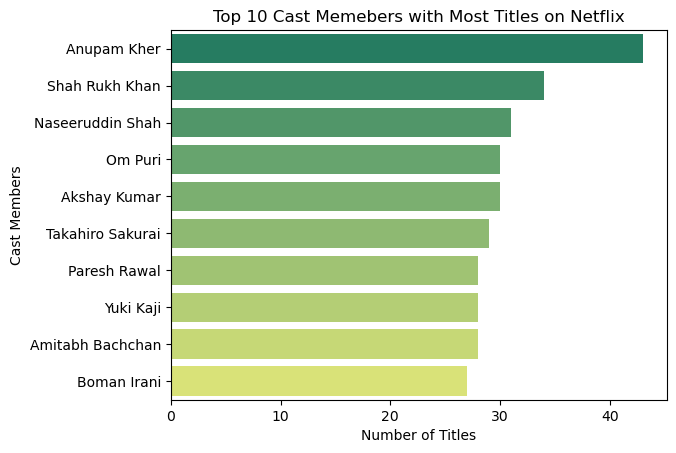

cast
Anupam Kher         43
Shah Rukh Khan      34
Naseeruddin Shah    31
Om Puri             30
Akshay Kumar        30
Takahiro Sakurai    29
Paresh Rawal        28
Yuki Kaji           28
Amitabh Bachchan    28
Boman Irani         27
Name: count, dtype: int64

In [23]:
cast_members = df_net['cast'].str.split(', ').explode()
top10_cast = cast_members.value_counts().head(10)
sns.barplot(x = top10_cast.values, y= top10_cast.index, palette='summer')
plt.title('Top 10 Cast Memebers with Most Titles on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Cast Members')
plt.show()

top10_cast

#### 4. Which countries produce the most content ?

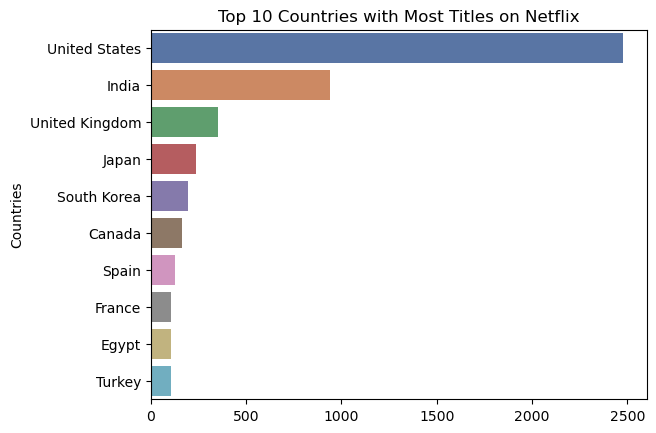

country
United States     2479
India              940
United Kingdom     350
Japan              238
South Korea        196
Canada             162
Spain              127
France             106
Egypt              105
Turkey             105
Name: count, dtype: int64

In [24]:
top_country =df_net['country'].value_counts().head(10)
sns.barplot(x= top_country.values, y= top_country.index, palette='deep')
plt.title('Top 10 Countries with Most Titles on Netflix')
plt.ylabel('Countries')
plt.show()

top_country

#### 5. How number of releases (release_year) for Movies and TV shows evolved over the years ?

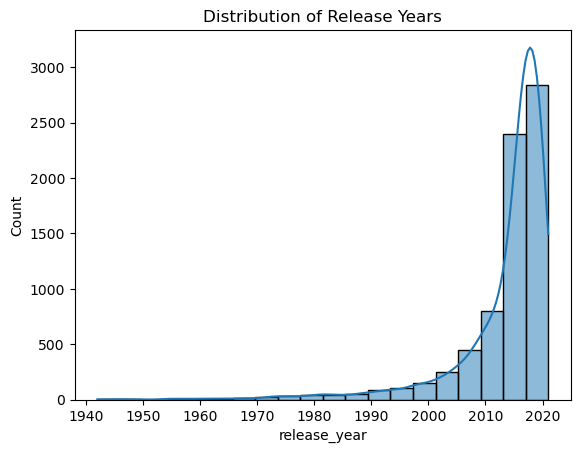

In [25]:
sns.histplot(df_net['release_year'], bins= 20, kde= True)
plt.title('Distribution of Release Years')
plt.show()

#### 6. What are the most common rating for Movies and TV Shows ?

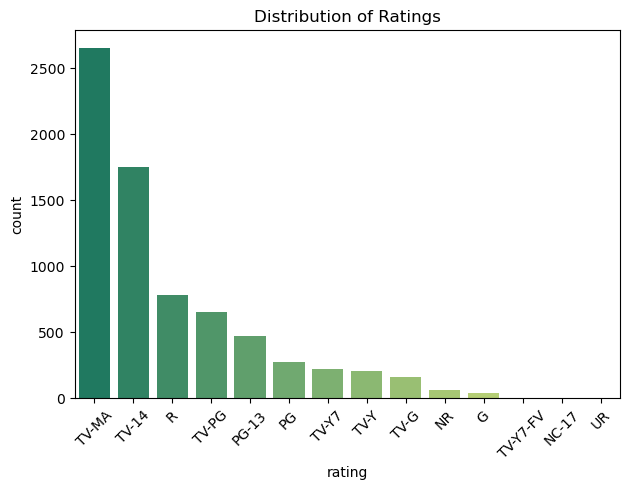

rating
TV-MA       2657
TV-14       1755
R            779
TV-PG        653
PG-13        470
PG           275
TV-Y7        222
TV-Y         209
TV-G         158
NR            62
G             40
TV-Y7-FV       4
NC-17          3
UR             3
Name: count, dtype: int64

In [26]:
rating_order = df_net['rating'].value_counts().index
sns.countplot(x= 'rating', data=df_net, order= rating_order, palette='summer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Distribution of Ratings')
plt.show()

df_net['rating'].value_counts()

#### 7. What are the Most Genres in Netflix ?

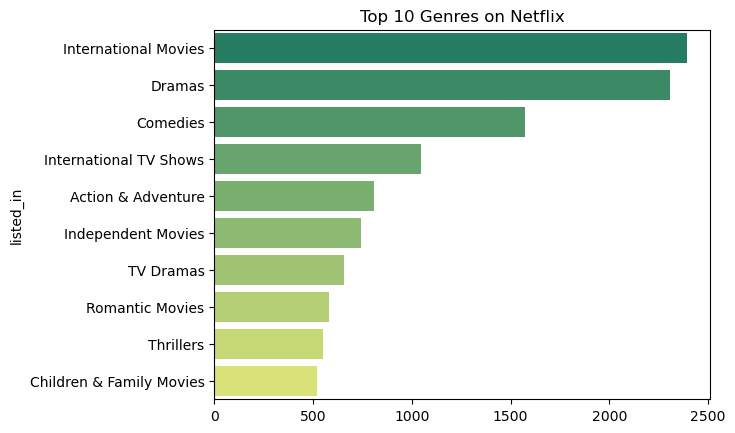

listed_in
International Movies        2392
Dramas                      2309
Comedies                    1574
International TV Shows      1047
Action & Adventure           811
Independent Movies           742
TV Dramas                    657
Romantic Movies              583
Thrillers                    549
Children & Family Movies     521
Name: count, dtype: int64

In [27]:
top_genres = df_net['listed_in'].str.split(', ').explode().value_counts().head(10)
sns.barplot(x = top_genres.values, y= top_genres.index, palette='summer')
plt.title('Top 10 Genres on Netflix')
plt.show()

top_genres

#### 8. What is the average duration of movies ?

In [28]:
movie_duration = df_net.loc[df_net['type'] == 'Movie'] ['duration'].str.replace(' min', '').astype(float).reset_index(drop= True)

average_duration = movie_duration.mean()

print(f'Average Movie Duration: {average_duration: .2f} Minutes')

Average Movie Duration:  102.14 Minutes


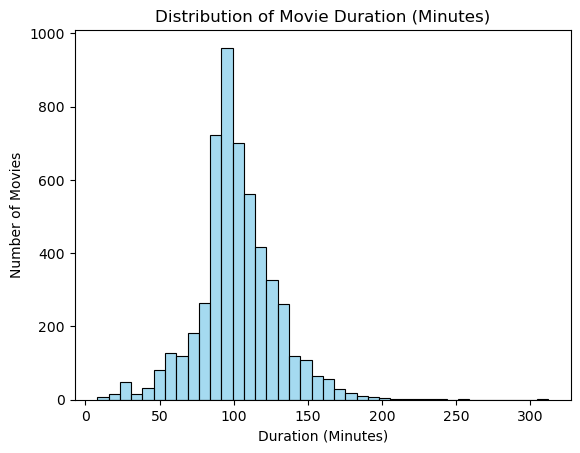

In [29]:
sns.histplot(movie_duration, bins= 40, color= 'skyblue')
plt.title('Distribution of Movie Duration (Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.show()

#### 9. How many seasons do TV Shows have on an average ?

In [30]:
tv_shows = df_net.loc[df_net['type'] == 'TV Show'] ['duration'].str.replace(
            ' Seasons', '').str.replace(' Season', '').astype(int).reset_index(drop= True)

average_tvshow_duration = tv_shows.mean()
print(f'Average TV Show Duration: {average_tvshow_duration: .2f} Seasons')

Average TV Show Duration:  1.91 Seasons


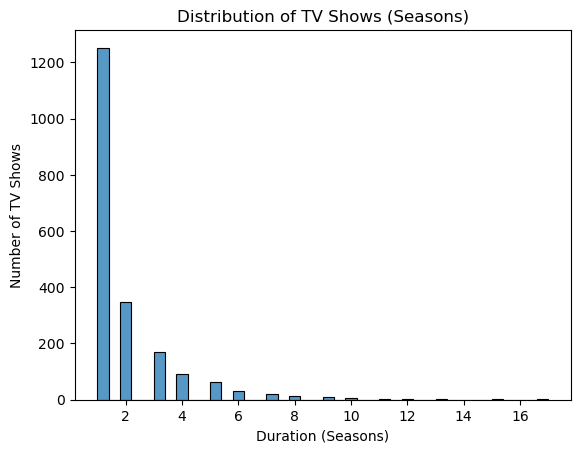

duration
1     1252
2      348
3      169
4       90
5       63
6       32
7       22
8       15
9        8
10       6
13       2
15       2
12       2
17       1
11       1
Name: count, dtype: int64

In [31]:
sns.histplot(tv_shows, bins= 40)
plt.title('Distribution of TV Shows (Seasons)')
plt.xlabel('Duration (Seasons)')
plt.ylabel('Number of TV Shows')
plt.show()

tv_shows.value_counts()

#### 10. Are there patterns or frequently occuring words in descriptions of adult movie titles ?

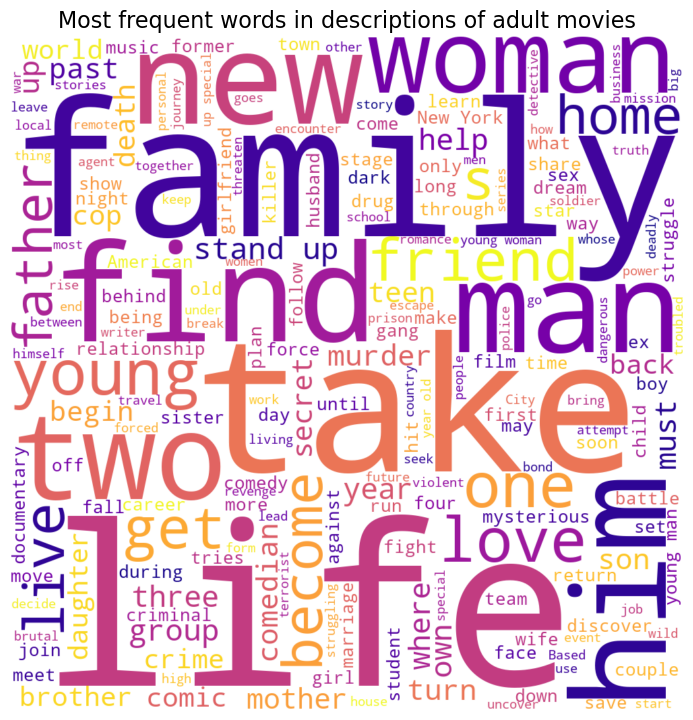

In [32]:
from wordcloud import WordCloud

adult_rated = df_net[(df_net['type'] == 'Movie') & (df_net['rating'].isin(['TV-MA', 'R']))].copy()

text = ' '.join(adult_rated['description'])

custom_stopwords = set([
    'the', 'and', 'with', 'his', 'her', 'who', 'in', 'of', 'their', 'for', 'that', 'to', 'from',
    'he', 'she', 'a', 'an', 'on', 'at', 'as', 'is', 'it', 'by', 'about', 'this', 'its', 'was',
    'are', 'be', 'has', 'have', 'they', 'them', 'will', 'after', 'before', 'when', 'while', 'over',
    'into', 'out', 'just', 'your', 'can', 'all', 'but', 'if'
])

wordcloud = WordCloud(width= 1000, height= 1000, background_color='white',colormap='plasma', stopwords= custom_stopwords).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation= 'bilinear')
plt.title('Most frequent words in descriptions of adult movies', fontsize= 16)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

#### 11. How many titles were added each year ?

Trend analysis of content addition

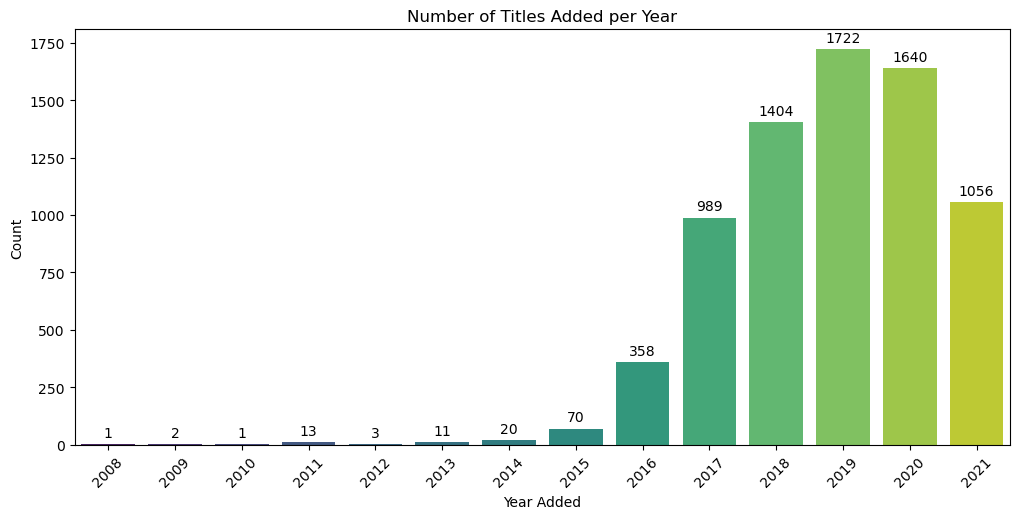

In [33]:
plt.figure(figsize=(10,5))

ax = sns.countplot(x='year', data=df_net, order=sorted(df_net['year'].unique()), palette='viridis')
plt.title('Number of Titles Added per Year')
plt.xticks(rotation=45)
plt.xlabel('Year Added')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container, fmt= '%d', label_type='edge', padding=3)
    
plt.tight_layout(pad=0)
plt.show()

#### 12. How many titles were added each month ?

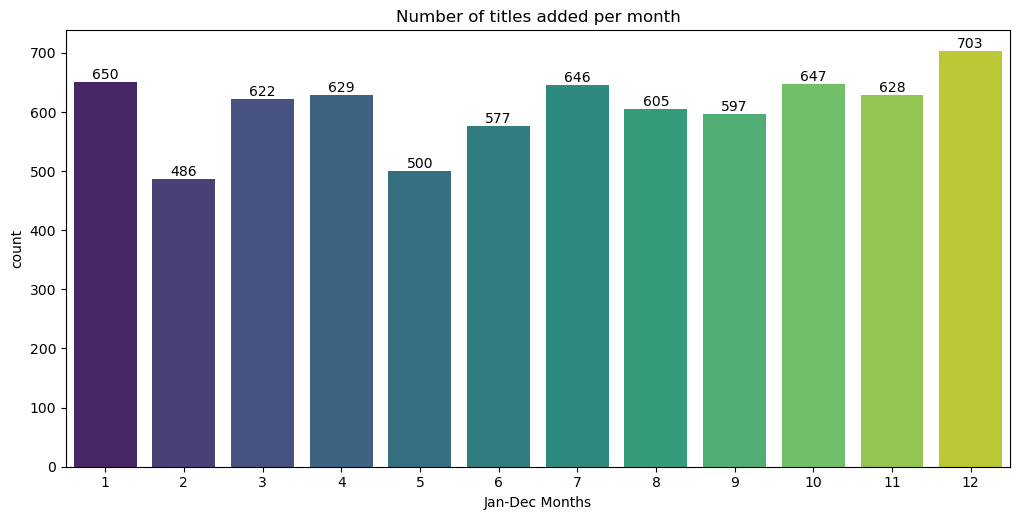

In [34]:
plt.figure(figsize=(10,5))

ax1= sns.countplot(x= 'month', data= df_net, order= range(1,13), palette='viridis')
plt.title('Number of titles added per month')
plt.xlabel('Jan-Dec Months')

for container in ax1.containers:
    ax1.bar_label(container)

plt.tight_layout(pad=0)
plt.show()

#### 13. How many titles were added each day ?

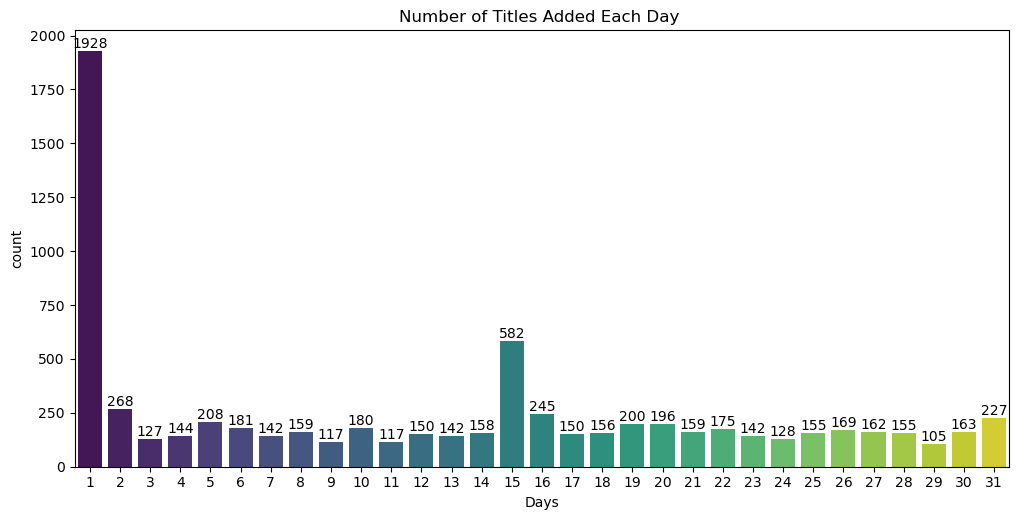

In [35]:
plt.figure(figsize=(10,5))

ax2 = sns.countplot(x= 'day', data= df_net, palette= 'viridis')
plt.title('Number of Titles Added Each Day ')
plt.xlabel('Days')

for container in ax2.containers:
    ax2.bar_label(container, fmt= '%d')

plt.tight_layout(pad= 0)
plt.show()

### 2. Bivariate Analysis

In [36]:
df_net.sample(3)

,show_id,type,title,director,cast,country,release_year,rating,duration,listed_in,description,day,month,year
4273,s4274,TV Show,Perfume,Not Available,"Friederike Becht, August Diehl, Wotan Wilke Mö...",Germany,2018,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas","When a singer is found murdered, with her scen...",21,12,2018
1115,s1116,Movie,Ferrari Ki Sawaari,Rajesh Mapuskar,"Sharman Joshi, Boman Irani, Ritwik Sahore, Par...",India,2012,TV-PG,133 min,"Comedies, International Movies, Sports Movies",A father winds up involved with a stolen Ferra...,1,4,2021
1764,s1765,Movie,Snowden,Oliver Stone,"Joseph Gordon-Levitt, Shailene Woodley, Zachar...","United Kingdom, France, Germany, United States",2016,R,134 min,"Dramas, Thrillers",This thriller traces Edward Snowden's journey ...,1,11,2020


#### 1. How does the distribution of content ratings differ from between Movies & TV Shows ?

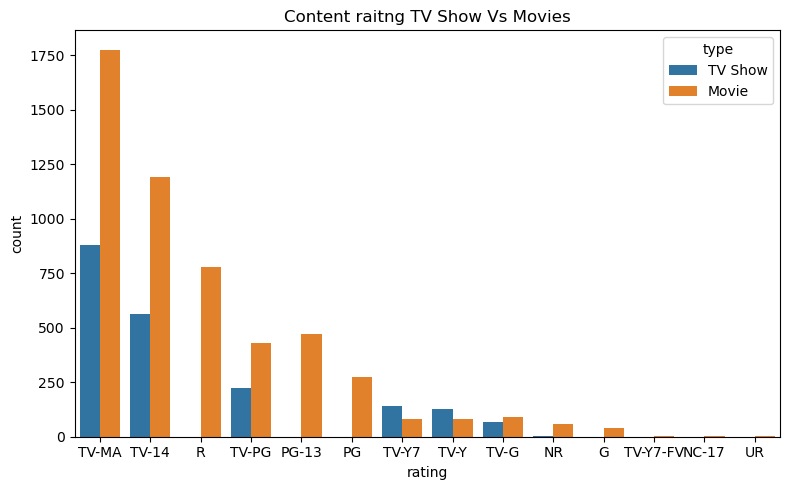

In [37]:
plt.figure(figsize=(8,5))
sns.countplot(x= 'rating', hue='type', data= df_net, order=df_net['rating'].value_counts().index)
plt.title('Content raitng TV Show Vs Movies')
plt.tight_layout()
plt.show()

#### 2. Distribution of content released over the years ?

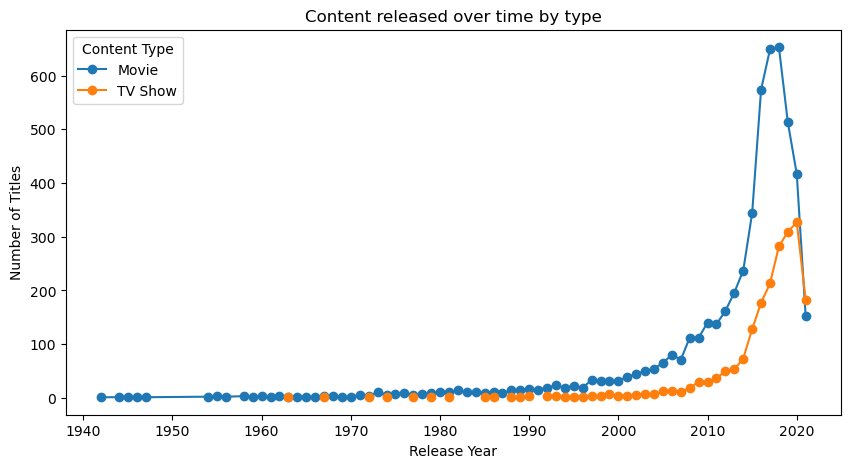

In [38]:
type_year = df_net.groupby(['release_year', 'type']).size().unstack().sort_index()
type_year.plot(kind='line', marker= 'o', figsize=(10,5))
plt.title('Content released over time by type')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Content Type')
plt.show()

#### 3. Distribution of Movie/TV Shows across the Top 10 countries by content volume.

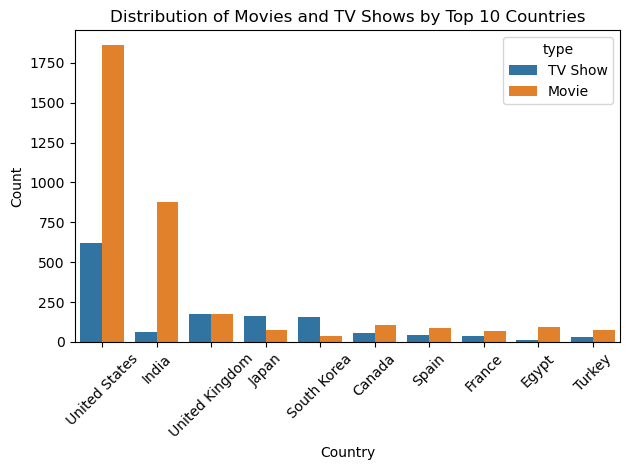

In [39]:
top_10_countries = df_net['country'].value_counts().head(10).index

df_top_countries = df_net[df_net['country'].isin(top_10_countries)]

sns.countplot(
    x='country', 
    hue='type', 
    data= df_top_countries, 
    order= top_10_countries)

plt.title('Distribution of Movies and TV Shows by Top 10 Countries')
plt.xticks(rotation = 45)
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#### 4. Distribution of Movie/TV Shows across the Top 10 Directors.

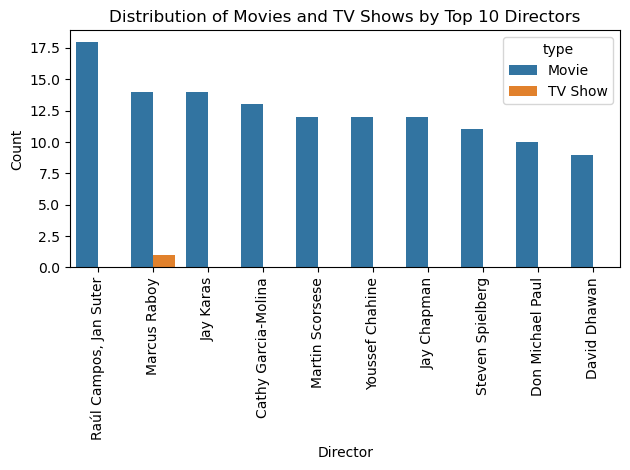

In [40]:
# df_net_director = df_net[df_net['director'] != 'Not Available']
# top10_directors = df_net_director['director'].value_counts().head(10)
# Above are previously defined variables in univariate analysis

top10_directors
df_top_director = df_net_director[df_net_director['director'].isin(top10_directors.index)]

sns.countplot(
    x= 'director', 
    hue='type', 
    data= df_top_director, 
    order= top10_directors.index)

plt.title('Distribution of Movies and TV Shows by Top 10 Directors')
plt.xticks(rotation=90)
plt.xlabel('Director')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### 5. How does the yearly trend of content addition differ between Movies and TV Shows ?

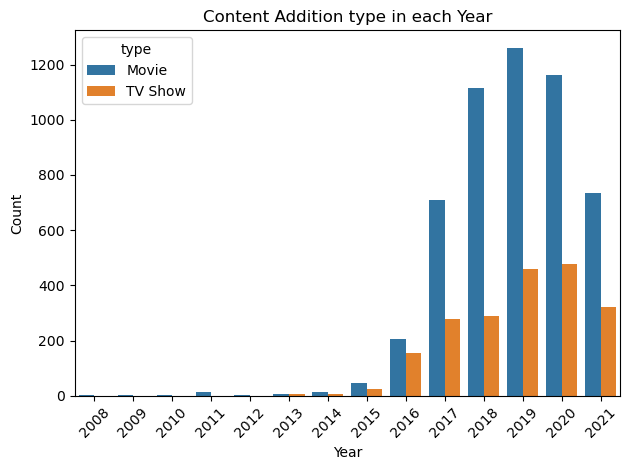

In [41]:
sns.countplot(x='year', hue= 'type', data= df_net)
plt.title('Content Addition type in each Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.show()

#### 6. How does monthly trend of content addition differ between Movies and TV Shows ?

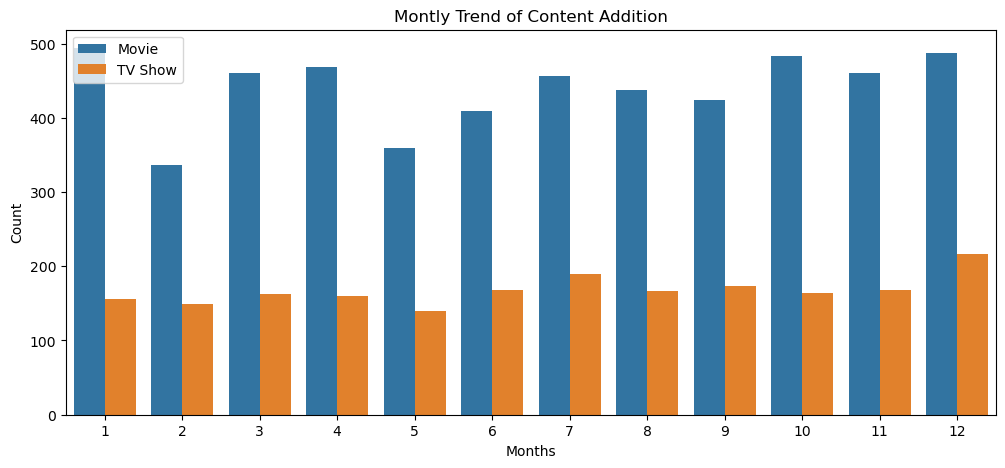

In [42]:
plt.figure(figsize=(12,5))
sns.countplot(x='month', hue='type', data= df_net)
plt.title('Montly Trend of Content Addition')
plt.xlabel('Months')
plt.ylabel('Count')
plt.legend()
plt.show()

#### 7. Which genres dominate in recent years, and how do their trends change over time ?

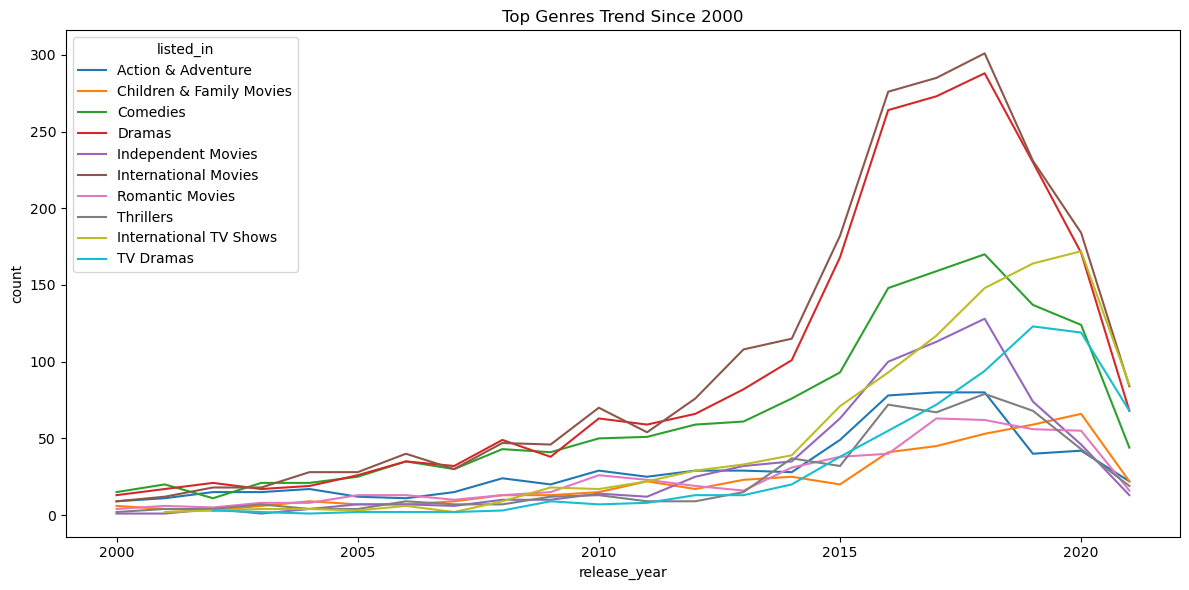

In [43]:
df_recent = df_net[df_net['release_year'] >= 2000].copy()

df_exploded = (df_recent
    .assign(listed_in = df_recent['listed_in'].str.split(', '))
    .explode('listed_in'))

top_genres = (df_exploded['listed_in'].value_counts().head(10).index)

genre_year_top = (
    df_exploded[df_exploded['listed_in'].isin(top_genres)]
    .groupby(['release_year', 'listed_in'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12,6))
sns.lineplot(
    x='release_year', 
    y='count', 
    hue= 'listed_in', 
    data= genre_year_top)

plt.title('Top Genres Trend Since 2000')
plt.tight_layout()
plt.show()

#### 8. Which genres tend to have longer or shorter movie durations ?

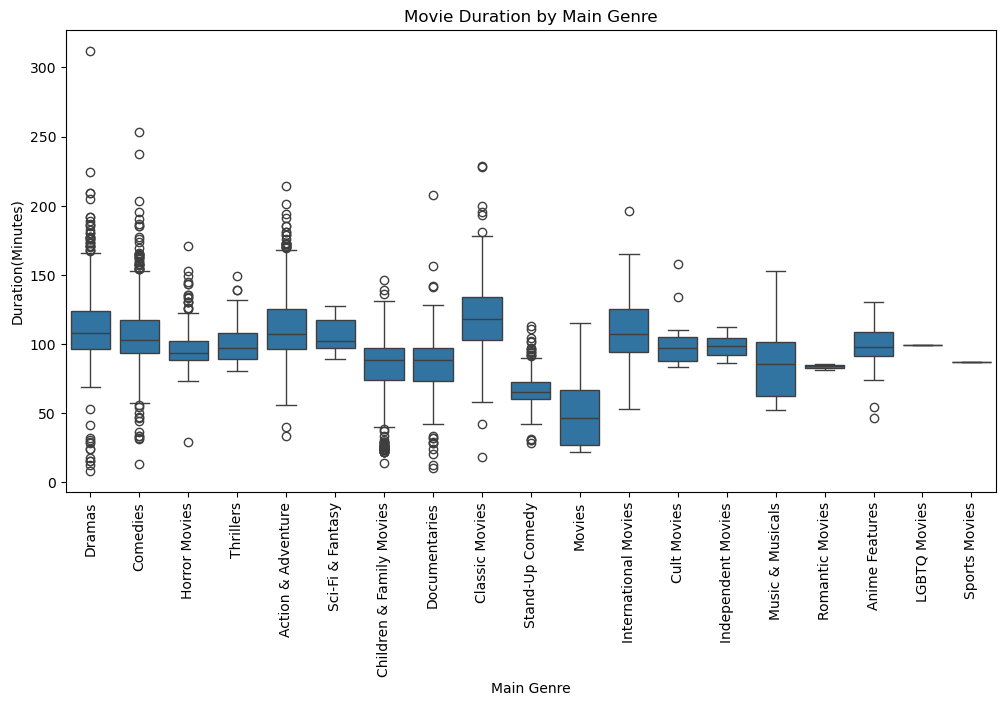

In [44]:
df_movies =df_net[df_net['type'] == 'Movie'].copy()

df_movies['duration_min'] = (df_movies['duration'].str.extract('(\d+)')[0].astype('int64'))

df_movies['main_genre'] = df_movies['listed_in'].str.split(', ').str[0]

plt.figure(figsize=(12,6))
sns.boxplot(x='main_genre', y='duration_min', data= df_movies)
plt.title('Movie Duration by Main Genre')
plt.xlabel('Main Genre')
plt.ylabel('Duration(Minutes)')
plt.xticks(rotation=90)
plt.show()

#### 9. How do children's content ratings (TV-Y and TV-G) differ across top countries ?

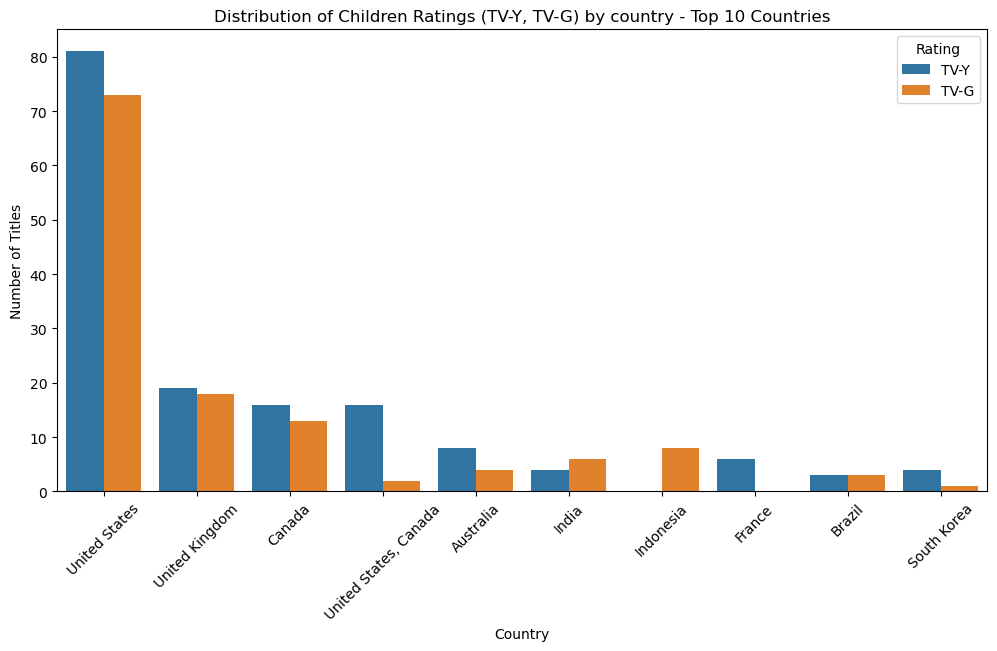

In [45]:
kids_rating = df_net[df_net['rating'].isin(['TV-Y', 'TV-G'])].copy()

top_countries = (kids_rating['country'].value_counts()
                 .head(10)
                 .index
                 .tolist())

top_rating_by_country = kids_rating[kids_rating['country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.countplot(x='country', 
                hue='rating', 
                data= top_rating_by_country,
                order= top_countries)
plt.title('Distribution of Children Ratings (TV-Y, TV-G) by country - Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title= 'Rating')
plt.show()

#### 10. How does the average number of seasons per TV show evolved over time ?

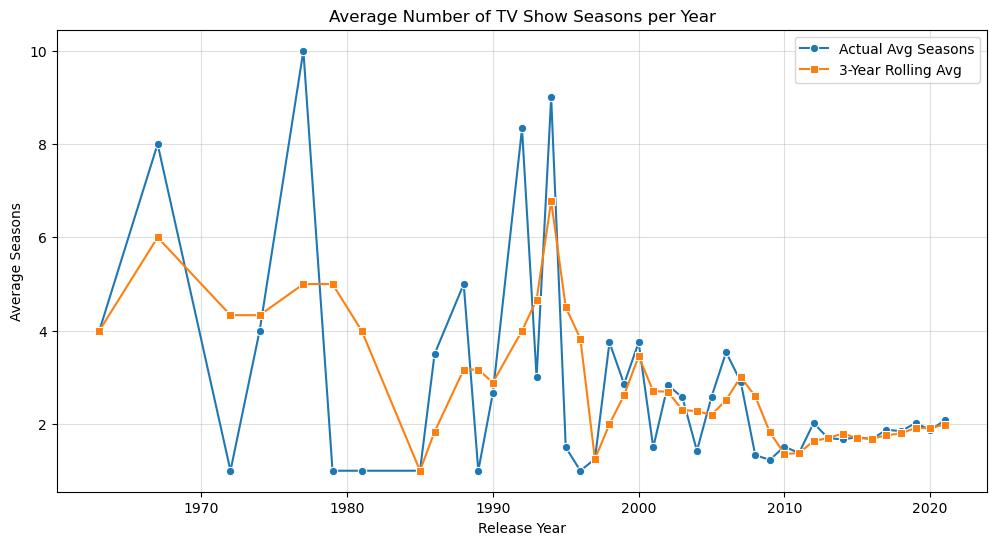

In [46]:
tv_shows = df_net[df_net['type'] == 'TV Show'].copy()

tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(int)

tv_shows = tv_shows.dropna(subset=['release_year', 'seasons'])

avg_seasons_per_year = (tv_shows
                        .groupby('release_year')['seasons'].mean()
                        .reset_index()
                        .sort_values('release_year'))

avg_seasons_per_year['rolling_avg'] = (avg_seasons_per_year['seasons']
                                       .rolling(3, min_periods=1)
                                       .mean())
plt.figure(figsize=(12,6))

sns.lineplot(x='release_year', 
             y= 'seasons', 
             data= avg_seasons_per_year,
             label= 'Actual Avg Seasons',
             marker= 'o')

sns.lineplot(x='release_year', 
             y= 'rolling_avg', 
             data= avg_seasons_per_year,
             label= '3-Year Rolling Avg',
             marker= 's')
plt.title('Average Number of TV Show Seasons per Year')
plt.xlabel('Release Year')
plt.ylabel('Average Seasons')
plt.grid(alpha=0.4)
plt.show()

## Recommendation System

#### Content-based recommendations system using TF-IDF on combined features

In [47]:
# Creating a copy of original dataframe
df_rec = df_net.copy()

In [48]:
# handling missing values

cols = ['title', 'description', 'listed_in', 'director', 'cast']
for col in cols:
    df_rec[col] = df_rec[col].fillna('')

In [49]:
# Create combined feature for content-based filtering

df_rec['combined'] = (df_rec['title'] + ' ' +
                      df_rec['description'] + ' ' +
                      df_rec['listed_in'] + ' ' +
                      df_rec['director'] + ' ' +
                      df_rec['cast'])

In [50]:
# Convert text to TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words= 'english')

tfidf_matrix = tfidf.fit_transform(df_rec['combined'])

In [51]:
# Compute cosine similarity

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [52]:
# Reset index to ensure it is sequential

df_rec = df_rec.reset_index(drop=True)

In [53]:
# Creating normalized title column for easier matching

df_rec['title_normalized'] = df_rec['title'].str.lower().str.strip()

In [54]:
# Recommendation function

def recommend(title, top_n=5):

    title = title.lower().strip()

    if title not in df_rec['title_normalized'].values:
        return f"Title {title} not found in the dataset."
    
    idx = df_rec[df_rec['title_normalized'] == title].index[0]

    scores = list(enumerate(cosine_sim[idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1: top_n+1]

    indices = [i[0] for i in scores]

    return df_rec.iloc[indices][['title', 'listed_in']]

In [55]:
# Text

recommend('sanju')

,title,listed_in
3727,PK,"Comedies, Dramas, International Movies"
734,3 Idiots,"Comedies, Dramas, International Movies"
3875,Lust Stories,"Comedies, Dramas, International Movies"
5695,Haseena Maan Jaayegi,"Action & Adventure, Comedies, Dramas"
5043,Anwar,"Dramas, Independent Movies, International Movies"


In [56]:
recommend('the karate kid')

,title,listed_in
376,The Karate Kid Part III,"Children & Family Movies, Dramas"
375,The Karate Kid Part II,"Action & Adventure, Children & Family Movies, ..."
1009,Cobra Kai,"TV Action & Adventure, TV Comedies, TV Dramas"
1286,The Next Karate Kid,"Action & Adventure, Dramas, Sports Movies"
4634,Across Grace Alley,Dramas


In [57]:
"""defined function to check titles only from from india"""

def indian_movies(n=10):
    
    df_ind = df_net[
        (df_net['country'].str.contains('India', na=False)) & 
        (df_net['type'] == 'Movie')
        ]
    
    return df_ind['title'].sample(min(n, len(df_ind)))

In [58]:
# Testing indian_movies function

indian_movies()

3206                          The Zoya Factor
7803                              Punjab 1984
4225                                 Taramani
8114                      Sudani from Nigeria
2278                                 Mary Kom
199                                Koi Aap Sa
2850    The Last Bomb of the Second World War
4335                               Chal Bhaag
4561                                  Delhi 6
6907                                   Haapus
Name: title, dtype: object